# Schema and Data Quality

This notebook aims to explore the schema of the SPD Calls dataset and examine missing values in the dataset.

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
from spd_snapshot import load_spd_call_snapshot
from spd_eda import summarize_spd_calls
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


df, metadata = load_spd_call_snapshot(
    PROJECT_ROOT / "data" / "processed"
)

display(df.head())
summary = summarize_spd_calls(df)
print(summary)

,cad_event_number,cad_event_original_time_queued,cad_event_arrived_time,cad_event_clearance_description,call_sign_dispatch_id,call_type,priority,initial_call_type,final_call_type,cad_event_response_category,dispatch_precinct,dispatch_sector,dispatch_beat,dispatch_neighborhood,dispatch_latitude,dispatch_longitude,count_of_officers,event_group
0,2025000204424,2025-07-20 00:00:56,2025-07-20 06:23:02,unable to locate incident or complainant,20250002044241K2,911,2,robbery (incl strong arm),robbery - strong arm,spd,west,king,k1,downtown commercial,NaN,NaN,2,robbery
1,2025000204425,2025-07-20 00:02:32,2025-07-20 00:12:46,unable to locate incident or complainant,20250002044253K03,911,1,unknown - ani/ali - landline (includes open line),disturbance - other,spd,west,king,k3,chinatown/international district,47.599200,-122.315680,1,disturbance
2,2025000204426,2025-07-20 00:03:04,2025-07-20 00:03:04,assistance rendered,2025000204426243,onview,7,directed patrol activity,directed patrol activity,spd,east,edward,e1,capitol hill,NaN,NaN,1,directed patrol
3,2025000204427,2025-07-20 00:03:19,2025-07-20 00:10:05,physical arrest made,20250002044273U23,911,2,burg - comm burglary,burglary - non residential/commercial,spd,north,lincoln,l1,lakecity,47.733936,-122.311398,2,burglary
4,2025000204427,2025-07-20 00:03:19,2025-07-20 00:10:05,physical arrest made,20250002044273N21,911,2,burg - comm burglary,burglary - non residential/commercial,spd,north,lincoln,l1,lakecity,47.733936,-122.311398,1,burglary


{'total_calls': 600508, 'unique_events': 346472, 'date_min': Timestamp('2025-07-20 00:00:56'), 'date_max': Timestamp('2026-07-19 23:59:58'), 'unique_event_groups': 53, 'unique_neighborhoods': 60, 'median_priority': 2.0, 'median_officers': 1.0, 'event_group_counts': {'traffic': 79606, 'disturbance': 72370, 'suspicious circumstances': 70398, 'assist public': 49400, 'domestic disturbance/violence': 31714, 'assaults': 31562, 'crisis complaint': 31060, 'assist other agency': 25382, 'prowler': 22825, 'premise checks': 22281, 'theft': 21955, 'automobiles': 15942, 'directed patrol': 15553, 'burglary': 12059, 'narcotics': 10342, 'warrant services/order': 8916, 'other': 7977, 'property destruction (damage)': 6179, 'robbery': 6169, 'mischief & nuisance': 5772, 'casualty (non-traffic. non-criminal, including man down, injured & sick person, doa)': 5402, 'hazards': 5186, 'person missing/found': 4004, 'assigned duty': 3931, 'alarms, false': 3618, 'weapon, person with': 3367, 'sex offenses (non-rape)

In [7]:
# add some EDA and quality checks
df["cad_event_original_time_queued"].min(), df["cad_event_original_time_queued"].max()
display(df.describe())

,cad_event_original_time_queued,cad_event_arrived_time,priority,dispatch_latitude,dispatch_longitude,count_of_officers
count,600508,555726,600508.000000,454711.000000,454711.000000,600508.000000
mean,2026-01-22 02:08:30.528513,2026-01-22 02:18:37.860162,2.912454,46.460563,-119.404376,1.248495
min,2025-07-20 00:00:56,2025-07-20 00:03:04,1.000000,-1.000000,-122.432252,1.000000
25%,2025-10-21 03:11:49,2025-10-21 07:06:26,2.000000,47.581469,-122.345223,1.000000
50%,2026-01-23 19:55:03,2026-01-23 19:51:17.500000,2.000000,47.612889,-122.327294,1.000000
75%,2026-04-27 02:24:20,2026-04-26 23:50:56.500000,3.000000,47.661029,-122.311952,1.000000
max,2026-07-19 23:59:58,2026-07-20 09:34:07,9.000000,47.775306,0.000000,4.000000
std,NaN,NaN,1.916709,7.382640,18.643642,0.432499


cad_event_number is unique: False
Head of cad_event_number frequencies: 
cad_event_number
2025000353113    100
2026000042145     82
2025000350658     57
2025000328199     52
2025000251199     51
Name: count, dtype: int64
call_sign_dispatch_id is unique: True


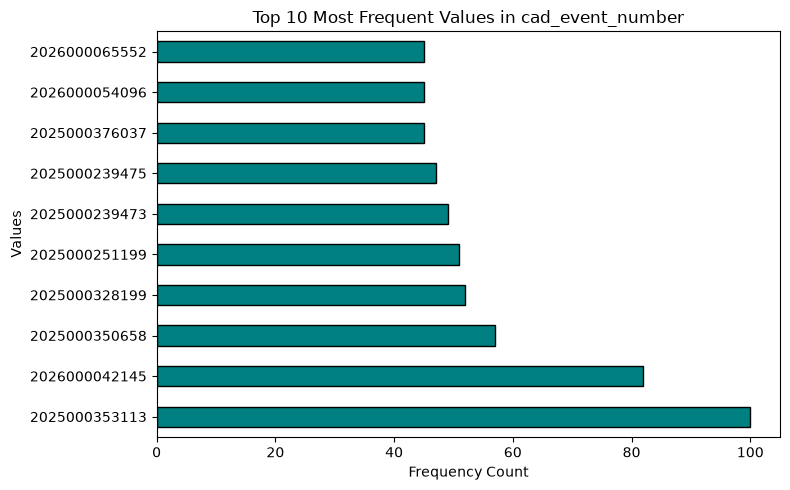

In [8]:

print(f"cad_event_number is unique: {df['cad_event_number'].is_unique}")
print(f"Head of cad_event_number frequencies: \n{df['cad_event_number'].value_counts().head(5)}")
print(f"call_sign_dispatch_id is unique: {df['call_sign_dispatch_id'].is_unique}")

# 3. Create a Distribution Chart of Unique vs. Duplicate Counts
plt.figure(figsize=(8, 5))
value_counts = df['cad_event_number'].value_counts()
value_counts.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title(f'Top 10 Most Frequent Values in cad_event_number')
plt.xlabel('Frequency Count')
plt.ylabel('Values')
plt.tight_layout()
plt.show()


### Row grain and refresh strategy

`cad_event_number` is not unique, meaning the dataset is not one row per CAD event. Multiple rows can belong to the same CAD event.

`call_sign_dispatch_id` appears to be unique across rows, so the pipeline treats it as the row-level deduplication key for incremental refreshes.

Dashboard metrics should distinguish between:

- unique CAD call events, counted with `cad_event_number`
- dispatch/unit-response records, counted with row count or `call_sign_dispatch_id`

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_frame = pd.DataFrame(missing, index=None).reset_index()

missing_frame['percent_missing'] = ((missing_frame[0] / len(df)) * 100).round(2)
missing_frame['percent_missing'] = missing_frame['percent_missing'].astype(str) + '%'
headers = ['feature', 'number_missing', 'percent_missing']
missing_frame.columns = headers

#print("\n Missing Values in  Data:")
#display(missing_frame)

fig = px.bar(
    missing_frame,
    x="number_missing",
    y="feature",
    orientation='h',
    color="number_missing",          
    color_continuous_scale='Reds',
    labels={'number_missing': 'Number of Missing Values', 'feature': 'Features', 'percent_missing':'Percent Missing '},
    title='Missing Values in Data',
    hover_data={
        "number_missing": False,
        "feature": False,
        "percent_missing": True,
    },
)

fig.update_layout(
    template="plotly_dark",
    width=1200,
    height=800,
    coloraxis_showscale=False,
    title_font_size=24,
    title_x=0.532,
    title_y=.95,
    title_xanchor='center',
    margin=dict(t=150), 
    xaxis=dict(
        title_standoff=30,  
        tickangle=0,
        ticklabelstandoff=0, 
    ),
    yaxis=dict(
        tickangle=-45,
        title_standoff=30,   
        ticklabelstandoff=10,
    ),
    annotations=[
        dict(text=r"Latitude and Longitude have the same number of missing values in the past year (143,066) and 24.26% of all coordinates are missing in this snapshot",
            xref="paper", yref="paper",
            x=.485, y=1.14,    
            showarrow=False,
            font=dict(size=10, color="darkgray"),
            xanchor="center")
        ]
    
)

fig.update_traces(
    hovertemplate="Percent Missing = %{customdata[0]}<extra></extra>"
)

fig.show()


### Missingness

`cad_event_arrived_time` and `dispatch_sector` have a small proportion of their values missing (0.075 and 0.012 respectively) but the coordinates recorded for each event have nearly a quarter (a proportion of 0.243) of their values missing. This may complicate the process of plotting calls/events on a map.

For the plotting of maps we may need to:

- Include a filter that excludes entries with missing coordinates
- Have a note on the percentage of events with missing coordinates in the data used for plotting
- Use entries with area names present for chloropleth maps

In [10]:
from IPython.display import HTML, display

df["has_coordinates"] = (
    df["dispatch_latitude"].notna()
    & df["dispatch_longitude"].notna()
)

coordinate_by_event_group = (
    df
    .groupby("event_group")
    .agg(
        total_calls=("cad_event_number", "size"),
        mappable_calls=("has_coordinates", "sum"),
    )
    .reset_index()
)

coordinate_by_event_group["mappable_percent"] = (
    coordinate_by_event_group["mappable_calls"]
    / coordinate_by_event_group["total_calls"]
    * 100
).round(2)

completely_unmappable = coordinate_by_event_group[coordinate_by_event_group["mappable_percent"] == 0]["event_group"].tolist()
completely_unmappable = coordinate_by_event_group["event_group"].str.replace(r'\s*\([^)]*\)', '', regex=True).tolist()
completely_unmappable[-1] = 'person with weapon'  # Correct the last entry to provide some clarity
missing_plot_df = coordinate_by_event_group[(coordinate_by_event_group["mappable_percent"] < 33) & (coordinate_by_event_group["mappable_percent"] > 0)].sort_values(
    "mappable_percent",
    ascending=True,
)

fig = px.bar(
    missing_plot_df,
    x="event_group",
    y="mappable_percent",
    title="Event Groups with Low Coordinate Coverage",
    width=1200,   
    height=800,   
)

fig.update_traces(marker_color="salmon")
fig.update_layout(title_x=0.5)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Event Group",
    yaxis_title="Percent of Calls with Coordinates",
    
    title_font=dict(size=24),
    
    margin=dict(
        l=120,    
        r=120,    
        t=160,    
        b=160,    
    ),
    
    xaxis=dict(
        title_standoff=50,  
        tickangle=0,
        ticklabelstandoff=18,
    ),
    yaxis=dict(
        title_standoff=50,   
        ticklabelstandoff=10,
        ticksuffix="%",
    ),
    annotations=[
        dict(text=f"Note: The following event groups have 0% mappable calls: {', '.join(completely_unmappable[:8])} <br> {', '.join(completely_unmappable[8:20])} <br> {', '.join(completely_unmappable[20:29])} <br> {', '.join(completely_unmappable[29:39])} <br> {', '.join(completely_unmappable[39:])}",
            xref="paper", yref="paper",
            x=.50, y=1.14,    
            showarrow=False,
            font=dict(size=9, color="darkgray"),
            xanchor="center")
        ]
)

# 4. Display the plot
fig.show()

